<a href="https://colab.research.google.com/github/ashiibansal/machine-learning-lab/blob/main/test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Practical Exam
## Hierarchical Clustering

Ashi Bansal - 23FE10CSE00394

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [14]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Pre-processing

In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [16]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})

Data Visualisation

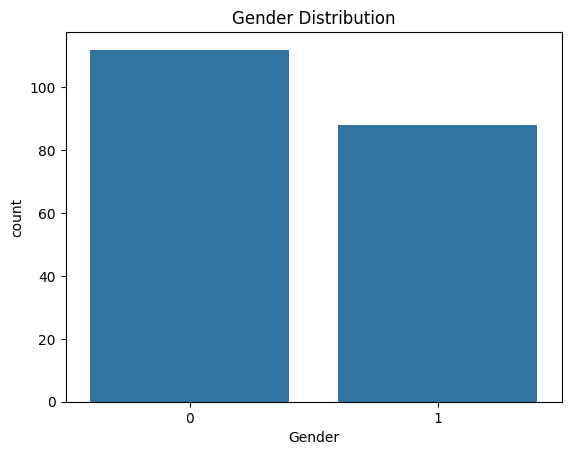

In [18]:
sns.countplot(x='Gender',data=df)
plt.title('Gender Distribution')
plt.show()

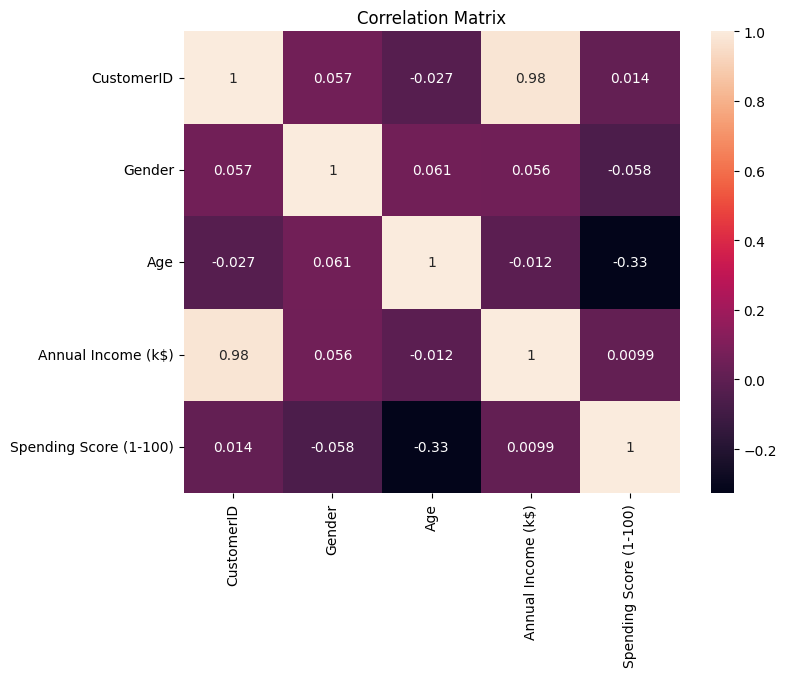

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Matrix')
plt.show()

Feature scaling

In [47]:
X= df[['Annual Income (k$)','Spending Score (1-100)']]

In [48]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(df)

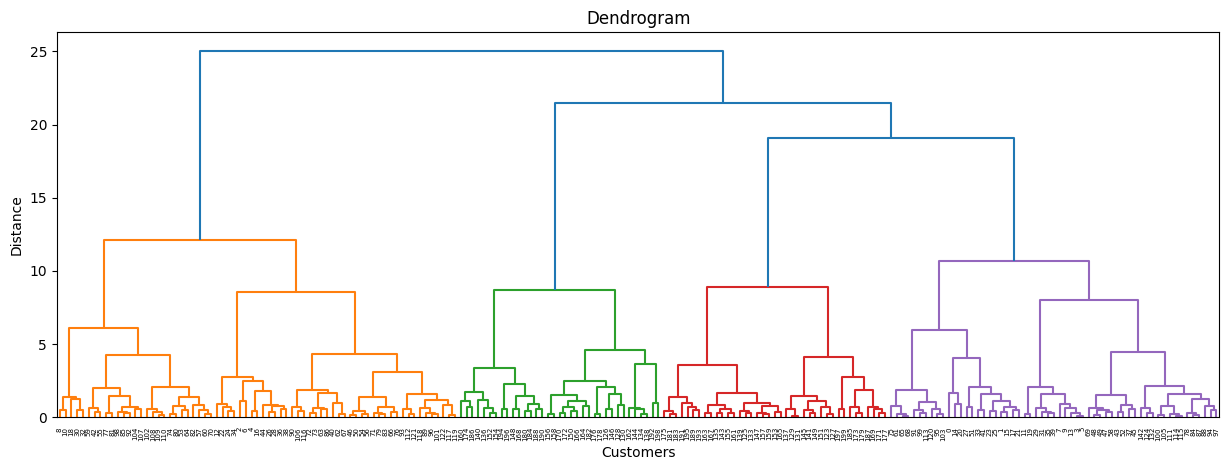

In [49]:
linked = linkage(X_scaled,method='ward')
plt.figure(figsize=(15,5))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

In [54]:
model = AgglomerativeClustering(n_clusters=4)
clusters = model.fit_predict(X_scaled)
df['Clusters'] = clusters

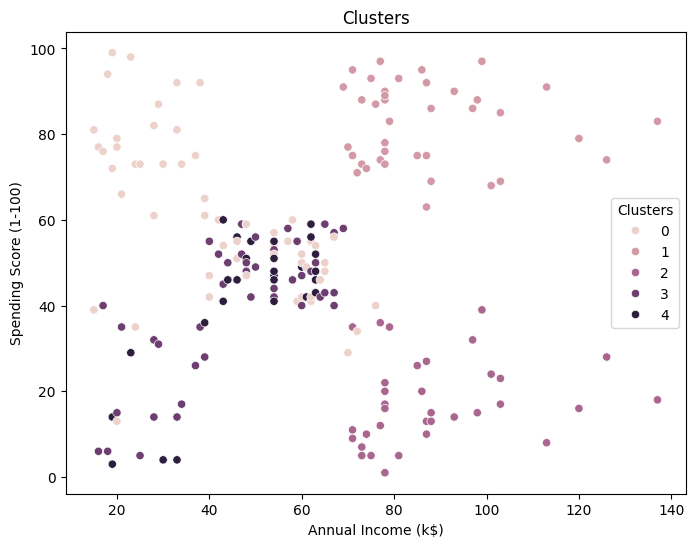

In [53]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='Clusters',data=df)
plt.title('Clusters')
plt.show()

Evaluation

In [55]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled,clusters)
print(score)


0.38292586102701004


In [57]:
from sklearn.metrics import calinski_harabasz_score
score = calinski_harabasz_score(X_scaled,clusters)
print(score)

100.36316507779473
